In [4]:
from pathlib import Path
import sys
import os

%load_ext autoreload
%autoreload 2

dir = Path().resolve().parents[1]

if dir not in sys.path:
    sys.path.append(str(dir))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
from nn import Unet1D, Returns, RMSELoss, EarlyStopping
from scripts import train, evaluate
from utils import log_transform, load_and_split_snp500
import torch
from torch.utils.data import DataLoader
import yfinance as yf
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [19]:
window = 256
data = load_and_split_snp500(window, transform_fn=log_transform)

In [20]:
train_snp500 = data["train"]
val_snp500 = data["val"]
test_snp500 = data["test"]

In [21]:
scaler = StandardScaler()
train_snp500_scaled = scaler.fit_transform(train_snp500.reshape(-1, 1))
val_snp500_scaled = scaler.transform(val_snp500.reshape(-1, 1))
test_snp500_scaled = scaler.transform(test_snp500.reshape(-1, 1))

In [22]:
train_snp500_scaled = torch.tensor(train_snp500_scaled).squeeze(1)
val_snp500_scaled = torch.tensor(val_snp500_scaled).squeeze(1)
test_snp500_scaled = torch.tensor(test_snp500_scaled).squeeze(1)

In [23]:
train_data = Returns(
  returns=train_snp500_scaled,
  window_size=window,
)
val_data = Returns(
  returns=val_snp500_scaled,
  window_size=window,
)
test_data = Returns(
  returns=test_snp500_scaled,
  window_size=window,
)

len(train_data), len(val_data), len(test_data)

(2158, 549, 549)

In [24]:
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, drop_last=True)
val_dataloader = DataLoader(val_data, batch_size=32, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=True, drop_last=True)

next(iter(train_dataloader)).size()

torch.Size([32, 1, 256])

In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
torch.cuda.manual_seed(42)
device

'cpu'

In [26]:
betas = torch.linspace(1e-4, 2e-2, 1000)
type(1 - betas)

torch.Tensor

In [33]:
encoder_in_channels = [1, 4, 8, 16]
encoder_out_channels = [4, 8, 16, 32]
decoder_in_channels = [32, 16, 8, 4]
decoder_out_channels = [16, 8, 4, 1]
attn_res = 16
n_res_block = 2
T = 1000
num_heads = 4
betas = torch.linspace(1e-4, 2e-2, T)
alpha_hats = torch.cumprod(
  input=1-betas,
  dim=0,
  dtype=torch.float32
)

model = Unet1D(
  attn_res=attn_res,
  n_res_block=n_res_block,
  encoder_in_channels=encoder_in_channels,
  encoder_out_channels=encoder_out_channels,
  decoder_in_channels=decoder_in_channels,
  decoder_out_channels=decoder_out_channels,
  T=T,
  num_heads=num_heads
)

In [34]:
dir = Path().resolve().parents[1]
save_path = dir / "models"


In [35]:
loss_fn = RMSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
  optimizer=optimizer,
  mode='min',
  factor=0.4,
  patience=2,
  threshold=1e-4
)

early_stop = EarlyStopping(
  model=model,
  save_path=save_path,
  patience=10,
  delta=0,
  file_name="model_256.pth",
  verbose=True
)

In [36]:
train_result = train(
  train_data=train_dataloader,
  val_data=val_dataloader,
  optimizer=optimizer,
  loss_fn=loss_fn,
  epochs=100,
  alpha_hats=alpha_hats,
  model=model,
  scheduler=None,
  early_stopping=early_stop,
  device=device,
  T=T
)

  1%|          | 1/100 [00:12<20:11, 12.23s/it]

Epoch : 0 | train_loss : 1.92 | val_loss : 1.82
New best model found. Current loss: 1.8185104061575497


  2%|▏         | 2/100 [00:30<25:25, 15.57s/it]

Epoch : 1 | train_loss : 1.82 | val_loss : 1.74
New best model found. Current loss: 1.735017229528988


  3%|▎         | 3/100 [00:42<23:09, 14.33s/it]

...

Epoch : 23 | train_loss : 0.60 | val_loss : 0.72


 25%|██▌       | 25/100 [05:39<16:32, 13.23s/it]

Epoch : 24 | train_loss : 0.61 | val_loss : 0.72


 25%|██▌       | 25/100 [05:54<17:42, 14.16s/it]

Epoch : 25 | train_loss : 0.61 | val_loss : 0.69
Stopping early as no improvement has been observed
Best Loss 0.6694985417758718
Overwriting an existing model...
The best model has been saved
Early stopping at epoch : 25
Total training time: 354.05902886390686 seconds


In [37]:
test_result = evaluate(
  test_dataloader,
  loss_fn=loss_fn,
  model=model,
  alpha_hats=alpha_hats,
  T=T,
  device=device
)
test_result

0.5736581753281986

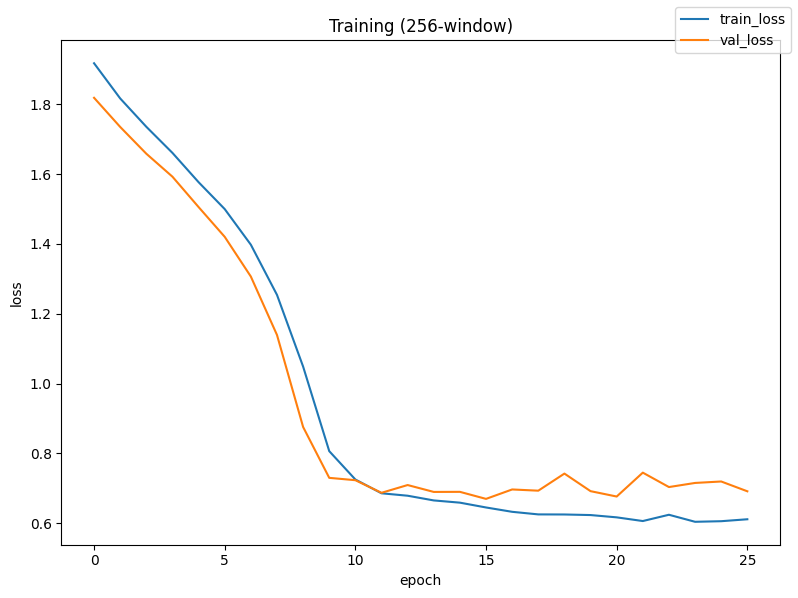

In [38]:
n_epochs = np.arange(0, len(train_result["train_loss"]))

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(n_epochs, train_result["train_loss"], label="train_loss")
ax.plot(n_epochs, train_result["val_loss"], label="val_loss")
# ax.set_xticks(n_epochs)

ax.set_title("Training (256-window)")
ax.set_ylabel("loss")
ax.set_xlabel("epoch")
fig.legend()

plt.tight_layout()
plt.show()